# Introduction to Machine Learning -- MC886
# Assignment 1 - Linear Models

**Professor:** Marcelo da Silva Reis\
**PED:** Heigon Alafaire Soldera Pires


In [1]:
# Please, enter your name and RA number in the lines below:
print("Lucas Treviso Bandeira", "|", "322979")
print("Mariana Dourado Ximenes de Sena Santos", "|", "300643")

Lucas Treviso Bandeira | 322979
Mariana Dourado Ximenes de Sena Santos | 300643



## Objective

The objective with this assignment is to explore **Linear Regression** and other
**Generalized Linear Models** to come up with the best model for the problem.
Remember, the goal is not just getting the code running, but gathering a deeper
understanding on **how** these algorithms work and **why** choosing them in the
first place.

Every model choice has implicit assumptions about the data, the goal here is to
understand the underlying assumptions and critically address the limitations
introduced by them.

### **Guidelines**
> Please, read these guidelines carefully

1. The questions can be answered in English or in Portuguese.

2. We incentivize visualizing the (training) data to gather insight about the
problem and the solutions. If you are not sure about an assumption, plot it!

3. The existing code in this notebook is just a mere reference. You are free to
change the code as much as you need. You will not be penalized for changing a 
function signature or implementing more functions/classes.
**Just make the code readable!**

4. The use of generative AI (ChatGPT, DeepSeek, Llama, GitHub Copilot, etc.) is
permitted to assist in completing assignments. In such cases the submitted work
**must** include a statement specifying the models used and, if
applicable, a transcription of the prompts employed to generate the code
incorporated into the solution.
However, using AI to analyse and discuss the results is discouraged.

5. The final performance of your model is not the main goal, explaining why the
model has such a performance (it being good or bad) is more important than the
metric value per se.

6. Metrics are not detached values, revisit the math behind them to understand
what they are trying to say about your model.

7. Do not hesitate in reaching the PED via Discord.

---
### **Dataset**
The dataset we will be using is the [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)
dataset, an hourly count of vehicles on the westbound Interstate 94, measured by
the MnDOT sensor ATR 301, roughly midway between Minneapolis and St. Paul (MN),
between 2015 and 2018.
Each observation joins the traffic counter with the weather reported for that
same hour and with the holiday calendar.

The data has 26677 samples with the following columns

feature | description | data type
--- | --- | ---
**instant** | Integer identifier | Integer
**date** | Date of the observation | Date
**season** | The season (1 Winter, 2 Spring, 3 Summer, 4 Fall) | Categorical
**yr** | Year (0 for 2015, 1 for 2016, 2 for 2017 and 3 for 2018) | Categorical
**mnth** | The month number | Categorical
**hr** | The hour number | Categorical
**holiday** | Whether the day is a national holiday (or the Minnesota State Fair) | Boolean
**weekday** | The day of the week (0 is Sunday) | Categorical
**workingday** | If the day is neither a holiday nor a weekend | Boolean
**weather** | Current weather (Clear, Clouds, Rain, Snow, Mist, ...) | Categorical
**weather_desc** | A longer description of the current weather | Categorical
**temp** | Temperature in °C | Continuous
**rain_1h** | Rain that fell during the hour, in mm | Continuous
**snow_1h** | Snow that fell during the hour, in mm | Continuous
**clouds_all** | Cloud cover in % | Continuous
**traffic_volume** | Count of vehicles reported in the hour | Integer

The goal will be inferring the traffic volume of an hour only using datetime and
weather information provided in the dataset.

> **Note:** this data comes from real sensors and was only lightly cleaned for
> you. Some hours are absent from the record and a few readings are physically
> implausible. Deciding what (if anything) to do about them is part of the
> assignment.

*Source: Hogue, J. (2019). Metro Interstate Traffic Volume. UCI Machine Learning
Repository (CC BY 4.0).*


In [2]:
# Importing the necessary libraries
# Remember to re-visit the Hands-on 1 notebooks to setup your environment
from numpy.typing import NDArray
import numpy as np

import pandas as pd
import random

# This notebook already has some plot examples in matplotlib, but feel free to
# use other libraries (e.g., seaborn, plotly) if you prefer
import matplotlib.pyplot as plt
import seaborn as sns

# To ensure reproducibility, set the random seed to your
# favorite number (e.g., your RA number)
np.random.seed(42)
random.seed(42)

# Do not tune this number to get better results, it is just to ensure that
# we all have the same random numbers and, therefore, the same results
# Re-run the notebook from the beginning (Run All) before submitting to classroom

In [3]:
# The dataset is available in the classroom assignment, ensure you have downloaded
# it and placed it in the same folder as this notebook

# Load the dataset
df = pd.read_csv("traffic_volume.csv")

df["date"] = pd.to_datetime(df["date"])
df.head()

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume
0,1,2015-06-11,3,0,6,20,0,4,1,Rain,light rain,14.44,0.0,0.0,92,2886
1,2,2015-06-12,3,0,6,18,0,5,1,Clear,Sky is Clear,24.39,0.0,0.0,0,4380
2,3,2015-06-12,3,0,6,20,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3095
3,4,2015-06-12,3,0,6,21,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3299
4,5,2015-06-13,3,0,6,21,0,6,0,Clouds,broken clouds,21.69,0.0,0.0,76,3040


Note that the data is time-ordered, and consecutive samples are (usually) 1 hour
apart from each other. Beware that the record is not perfectly regular: some
hours were never reported by the sensor.
The idea is to predict future traffic volume from past data, thus our evaluation
protocol must respect the temporal order.
Therefore, we select the first 80% samples to compose the training data, and the
remaining 20% will be used for testing purposes.

**Important:** Never take decisions over the test dataset, it must be only used after
all models are trained (in the Test Evaluation section).
Any decision made using test information is called [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)) and will be penalized.


In [4]:
train_size = int(0.8 * len(df))

train_df = df[:train_size]
test_df = df[train_size:]

# Securing that df will not be used anymore, to avoid mistakes
del df

print("Train set size:", len(train_df))
print("Test set size:", len(test_df))

Train set size: 21341
Test set size: 5336


---

## **Data Analysis and Preprocessing**

This part of the assignment aims to analyze the dataset and preprocess
the data for the models.


(0.5 points) 
First, consider possible problems in your dataset:
- Should you use all the features in the dataset?
- What features are important, are there missing values in them?
- Are there outliers in continous features?
- How should you handle the categorical features?
- How does the traffic volume change when features change?
- Are these feature correlated?

Do not plot any graph for now, just see some statistics (mean, count, data types).
You can manually explore the dataframe if you want.

In [5]:
train_df.describe()

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,21341.000000,21341,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000
mean,10671.000000,2016-11-16 00:53:50.738953,2.574809,1.352092,6.813177,11.471346,0.032707,3.000984,0.680943,9.058459,0.520919,0.000223,41.742749,3277.748981
min,1.000000,2015-06-11 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-29.760000,0.000000,0.000000,0.000000,0.000000
25%,5336.000000,2016-04-16 00:00:00,1.000000,1.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,1.000000,1250.000000
50%,10671.000000,2016-11-29 00:00:00,3.000000,1.000000,7.000000,11.000000,0.000000,3.000000,1.000000,11.080000,0.000000,0.000000,40.000000,3446.000000
75%,16006.000000,2017-07-12 00:00:00,4.000000,2.000000,10.000000,18.000000,0.000000,5.000000,1.000000,19.170000,0.000000,0.000000,90.000000,4915.000000
max,21341.000000,2018-02-19 00:00:00,4.000000,3.000000,12.000000,23.000000,1.000000,6.000000,1.000000,34.180000,9831.300000,0.510000,100.000000,7280.000000
std,6160.760383,NaN,1.143291,0.822834,3.447233,6.953911,0.177873,2.002400,0.466122,12.523845,67.301383,0.007825,39.245090,1964.269523


In [6]:
# Auxiliary code to display extra information about the dataset

print("DataFrame data types summary:\n\n{}\n".format(train_df.dtypes))

print("Number of missing values in train_df:\n{}\n".format(train_df.isna().sum().sum()))

print("Number of unique values in train_df:")
display(train_df.nunique())

DataFrame data types summary:

instant                    int64
date              datetime64[us]
season                     int64
yr                         int64
mnth                       int64
hr                         int64
holiday                    int64
weekday                    int64
workingday                 int64
weather                      str
weather_desc                 str
temp                     float64
rain_1h                  float64
snow_1h                  float64
clouds_all                 int64
traffic_volume             int64
dtype: object

Number of missing values in train_df:
0

Number of unique values in train_df:


instant           21341
date                976
season                4
yr                    4
mnth                 12
hr                   24
holiday               2
weekday               7
workingday            2
weather              10
weather_desc         34
temp               4446
rain_1h             187
snow_1h              12
clouds_all           22
traffic_volume     6133
dtype: int64

In [7]:
# Calculate statistics for the target variable after grouping

train_df.groupby("workingday")["traffic_volume"].agg(["mean", "median"])

,mean,median
workingday,,
0,2634.412836,2759.0
1,3579.185522,4278.0


> **Question:**
>
> Which of the previous questions can you properly answer without visualizing the data?
> What decisions can be made right now?

**Answer:**

*1. Should you use all the features in the dataset?*

Podemos responder parcialmente. Com base nas informações obtidas por meio de estatísticas descritivas aplicadas ao conjunto de treinamento, já é possível identificar algumas features potencialmente desnecessárias ou redundantes, que poderiam ser removidas do conjunto. A coluna "instant", por exemplo, atua apenas como um identificador dos registros e, portanto, não tende a fornecer informação relevante para a predição. A coluna "date" também pode ser considerada redundante, uma vez que sua informação temporal já está decomposta em outras features. Além disso, as colunas "weather" e "weather_desc" representam condições meteorológicas em diferentes níveis de granularidade. Entretanto, apenas pela análise de sua semântica não é possível determinar qual delas possui maior poder preditivo ou se ambas devem ser mantidas. Portanto, nesta etapa podemos remover features claramente não informativas e identificar possíveis redundâncias, mas uma seleção mais rigorosa deve considerar também a relação de cada variável com a variável alvo "traffic_volume".

*2. What features are important, are there missing values in them?*

Podemos afirmar que não existem valores ausentes, conforme retornado pela função train_df.isna().sum().sum(). Quanto à importância das features, estatísticas descritivas e análises univariadas, como as fornecidas por describe(), não são suficientes para determinar quais variáveis são mais relevantes para a predição de traffic_volume. Essas análises caracterizam cada feature de forma isolada e não avaliam diretamente sua relação com a variável alvo, sendo necessário expandirmos nossa análise com correlações ou modelos para extração de feature importance. 

*3. Are there outliers in continous features?*

Podemos responder, visto que há indícios de outliers a partir das estatísticas descritivas. Na feature "rain_1h", o valor máximo de 9831.3 é extremamente superior à média (0.52) e aos valores típicos da variável, sendo um forte candidato a outlier ou até mesmo a um possível erro de medição do equipamento e contribuindo para inflar o desvio padrão (67.30).

*4. How should you handle the categorical features?*

Podemos responder. Para um modelo de regressão linear, as features categóricas nominais, como "weather" e "weather_desc", devem ser transformadas em uma representação numérica, utilizando one-hot encoding por exemplo. Já as features binárias, como "holiday" e "workingday", por já estarem representadas por valores 0 e 1, não necessitam de codificação adicional. No caso das features temporais categóricas ("hr", "mnth", "weekday", "season"), por apresentarem uma natureza cíclica ao longo do conjunto de dados, tratá-las como valores inteiros pode introduzir relações artificiais de ordem, implicando também em uma transformação com one-hot encoding ou outra forma de codificação.

*5. How does the traffic volume change when features change?*

Podemos responder parcialmente por meio de análises entre cada feature e a variável alvo traffic_volume. Para features categóricas, uma abordagem inicial consiste em agrupar as observações por categoria e comparar estatísticas como média e mediana do volume de tráfego. No exemplo com "workingday", observamos que dias úteis (workingday = 1) apresentam maior volume de tráfego do que dias não úteis (workingday = 0). Isso sugere uma associação entre "workingday" e "traffic_volume", mas não isola uma relação causal entre as variáveis.

*6. Are these feature correlated?*

Não podemos responder diretamente a partir das estatísticas fornecidas por describe(). Porém, como análise inicial, podemos calcular uma matriz de correlação entre as features numéricas para identificar relações lineares, por exemplo. Entretanto, conforme citado na questão 4, várias features categóricas precisariam ser transformadas para resultarem em valores de correlação conceitualmente mais adequados.

---
(1.0 points) Now, explore the raw data, visualize their relationship with the target `traffic_volume`.
You can use boxplots to understand feature distributions, histograms to observe
the count frequency, explore the temporal correlation.

There is no minimum/maximum requirements for the exploratory data analysis, plot
as many graphs as you need to gather information from your problem.
After plotting, write about your findings, formulate hypothesis about unseen
patterns and ponder about the data preprocessing step.

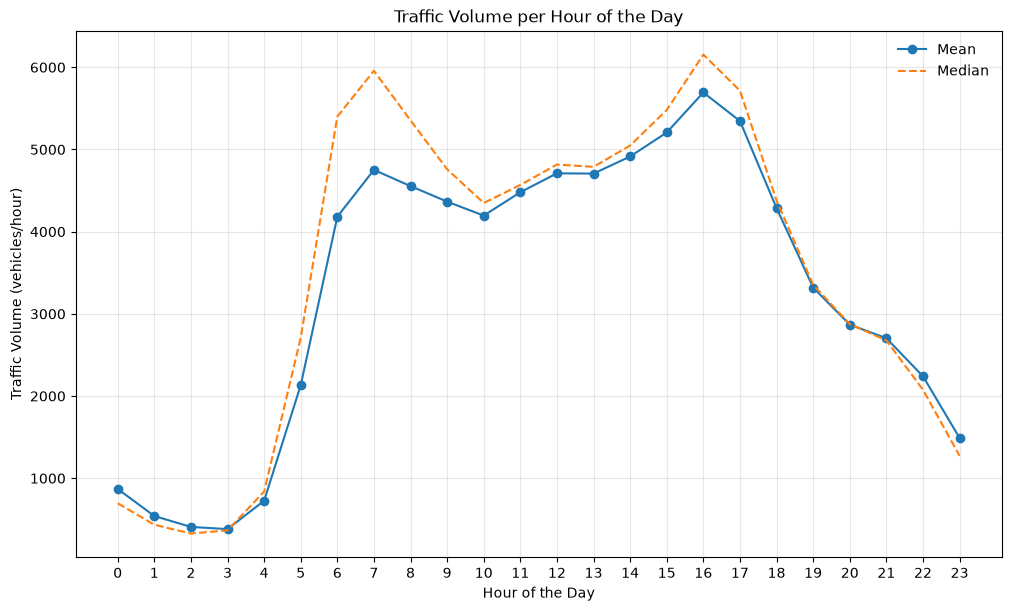

In [8]:
hourly_stats = train_df.groupby("hr")["traffic_volume"].agg(
    mean="mean",
    median="median",
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

ax.plot(hourly_stats.index, hourly_stats["mean"], marker="o", label="Mean")
ax.plot(
    hourly_stats.index,
    hourly_stats["median"],
    linestyle="--",
    label="Median",
)

ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Traffic Volume (vehicles/hour)")
ax.set_title("Traffic Volume per Hour of the Day")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.show()

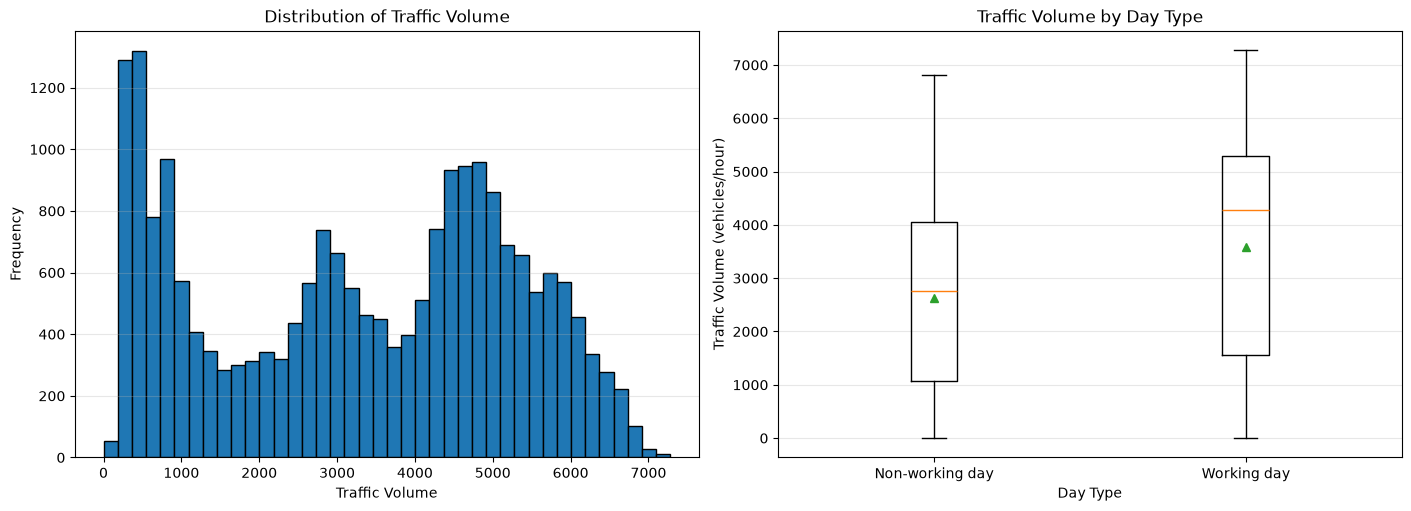

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].hist(train_df["traffic_volume"], bins=40, edgecolor="black")
axes[0].set_title("Distribution of Traffic Volume")
axes[0].set_xlabel("Traffic Volume")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)

traffic_by_day_type = [
    train_df.loc[train_df["workingday"] == 0, "traffic_volume"],
    train_df.loc[train_df["workingday"] == 1, "traffic_volume"],
]
axes[1].boxplot(traffic_by_day_type, showmeans=True)
axes[1].set_title("Traffic Volume by Day Type")
axes[1].set_xlabel("Day Type")
axes[1].set_ylabel("Traffic Volume (vehicles/hour)")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Non-working day", "Working day"])
axes[1].grid(axis="y", alpha=0.3)

plt.show()

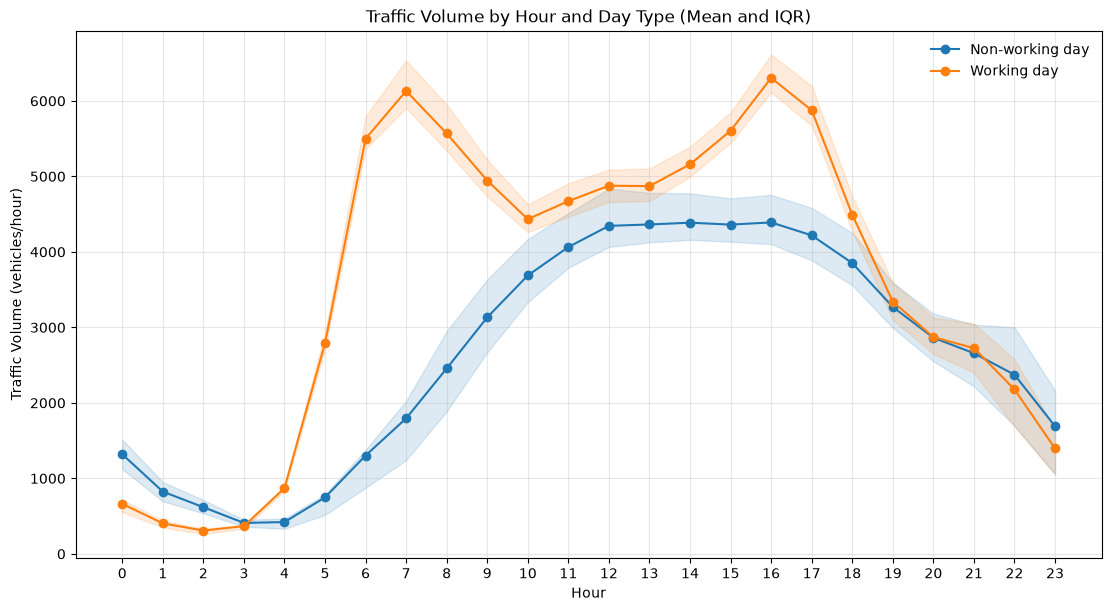

In [10]:
hour_working_stats = (
    train_df
    .groupby(["hr", "workingday"])["traffic_volume"]
    .agg(
        mean="mean",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
    )
)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

day_types = {0: "Non-working day", 1: "Working day"}
colors = {0: "tab:blue", 1: "tab:orange"}

for day_type, label in day_types.items():
    stats = hour_working_stats.xs(day_type, level="workingday")
    ax.fill_between(
        stats.index,
        stats["q25"],
        stats["q75"],
        color=colors[day_type],
        alpha=0.15,
    )
    ax.plot(
        stats.index,
        stats["mean"],
        color=colors[day_type],
        marker="o",
        label=label,
    )

ax.set_xlabel("Hour")
ax.set_ylabel("Traffic Volume (vehicles/hour)")
ax.set_title("Traffic Volume by Hour and Day Type (Mean and IQR)")
ax.set_xticks(range(24))
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.show()

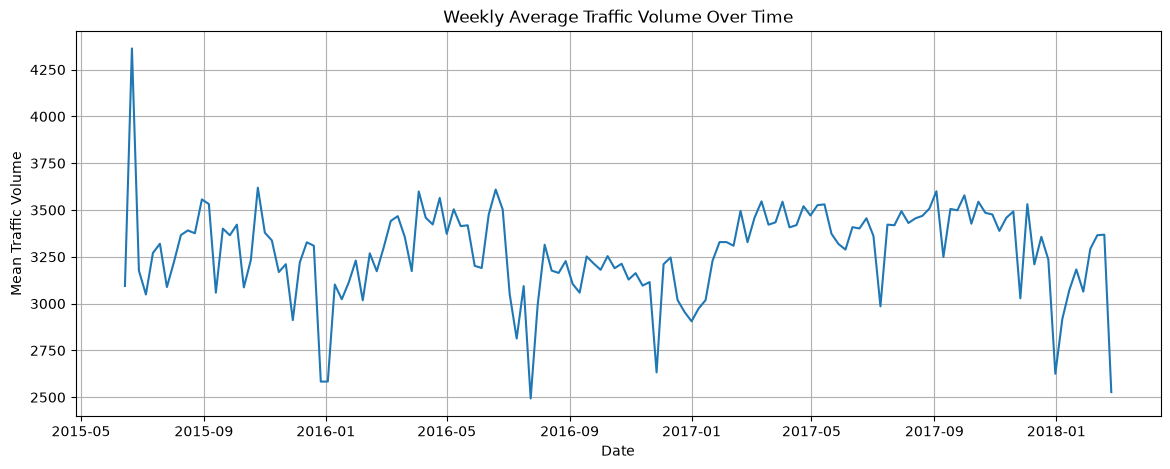

In [11]:
weekly_traffic = (
    train_df
    .set_index("date")
    ["traffic_volume"]
    .resample("W")
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(weekly_traffic.index, weekly_traffic.values)

plt.xlabel("Date")
plt.ylabel("Mean Traffic Volume")
plt.title("Weekly Average Traffic Volume Over Time")
plt.grid()

plt.show()

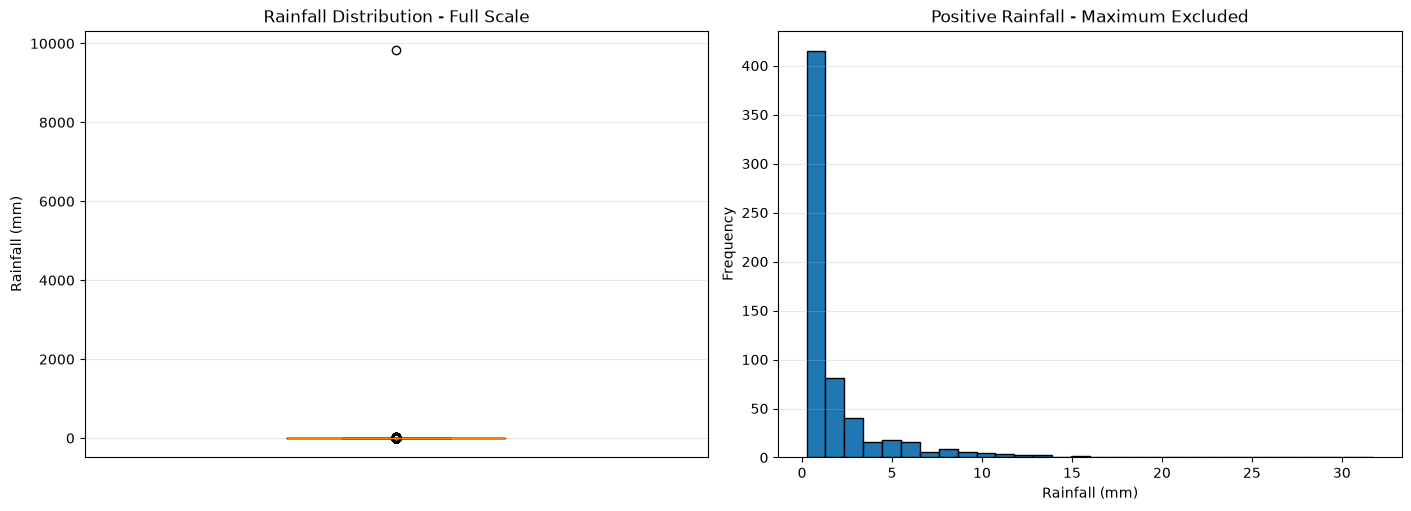

In [12]:
rain = train_df["rain_1h"]
extreme_rain_idx = rain.idxmax()
rain_without_extreme = rain.drop(index=extreme_rain_idx)
positive_rain_without_extreme = rain_without_extreme[rain_without_extreme > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].boxplot(rain, widths=0.35)
axes[0].set_title("Rainfall Distribution - Full Scale")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].set_xticks([])
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(positive_rain_without_extreme, bins=30, edgecolor="black")
axes[1].set_title("Positive Rainfall - Maximum Excluded")
axes[1].set_xlabel("Rainfall (mm)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", alpha=0.3)

plt.show()

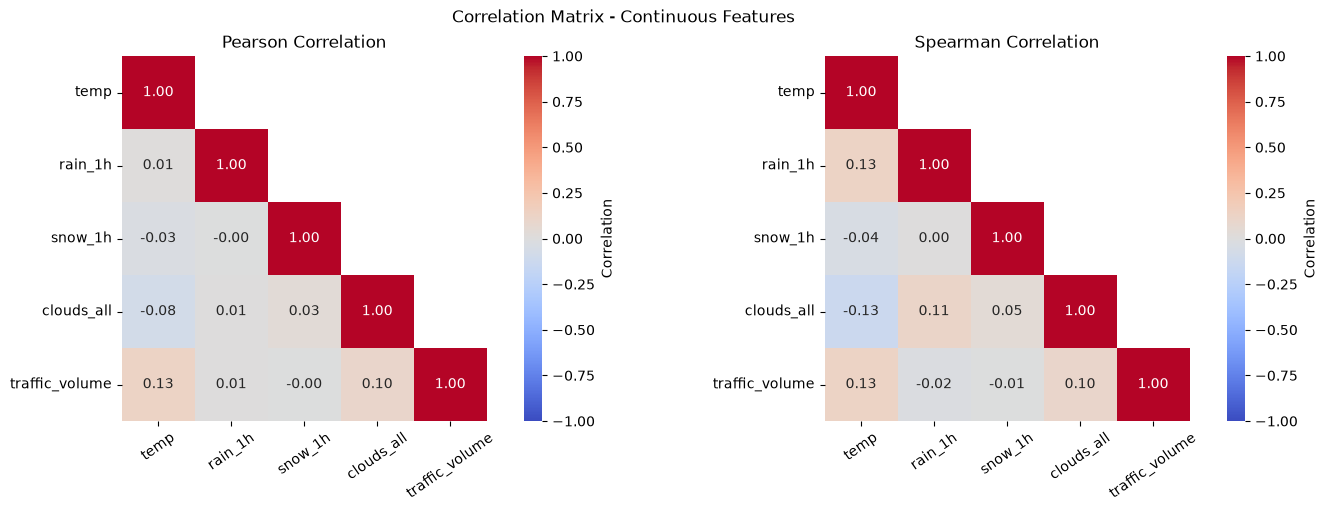

In [13]:
continuous_cols = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "traffic_volume"
]

correlations = {
    "Pearson": train_df[continuous_cols].corr(method="pearson"),
    "Spearman": train_df[continuous_cols].corr(method="spearman"),
}
mask = np.triu(np.ones_like(correlations["Pearson"], dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (method, corr) in zip(axes, correlations.items()):
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        ax=ax,
        cbar_kws={"label": "Correlation"},
    )
    ax.set_title(f"{method} Correlation")
    ax.tick_params(axis="x", labelrotation=35)
    ax.tick_params(axis="y", labelrotation=0)

fig.suptitle("Correlation Matrix - Continuous Features")
plt.show()

> **Question:**
> 
> How did the visualization help in understanding the data?
> Which questions were answered and what hypothesis are left to be tested? 
> 
> Have you decided to remove some feature from the dataset? Why?

O gráfico de "traffic_volume" por hora do dia revela uma variação do volume de tráfego ao longo das 24 horas. Durante a madrugada, o fluxo permanece em níveis baixos, aumenta rapidamente nas primeiras horas da manhã, mantém-se elevado durante o dia e apresenta um novo pico no final da tarde, seguido por uma redução durante a noite. A diferença entre média e mediana também varia conforme o horário, indicando que a distribuição de "traffic_volume" não mantém a mesma forma ao longo do dia. Esses padrões sugerem uma forte associação entre "hr" e a variável alvo e indicam que tratar "hr" simplesmente como uma variável numérica linear provavelmente não seria adequado, pois sua relação com o tráfego é claramente não linear.

Essa relação torna-se mais evidente quando "hr" é analisada junto com "workingday". Nos dias úteis, observam-se um pico pela manhã e outro no final da tarde, apresentando um padrão compatível com períodos de maior deslocamento. Nos dias não úteis, por outro lado, o crescimento do tráfego ocorre de maneira mais gradual, permanecendo relativamente estável durante grande parte do período diurno. Portanto, o efeito de "workingday" sobre "traffic_volume" parece variar de acordo com a hora do dia, sugerindo uma interação entre "hr" e "workingday". Essa observação é relevante para uma regressão linear, pois um modelo sem termos que permitam uma representação mais flexível de "hr", pode não ser capaz de capturar adequadamente esse comportamento.

----
### **Preprocessing**
(1.0 point) Now that you have a deeper insight about the problem, let's preprocess
the raw data with the necessary transformations and turn the data into an array,
ready to be fed into a model.

Create a function `preprocess_data` and make all required transformation, the
output must be a tuple (X, y) of numpy arrays, where X has shape (n_samples, n_features)
and y is a column array of shape (n_samples,).

Note that the distributions on the features in the test set may not coincide
with the ones in the train set, your preprocessing must take that into account
without peeking at test samples.

In [ ]:
def preprocess_data(df: pd.DataFrame) -> tuple[NDArray[np.float64], NDArray[np.float64]]:

    raise NotImplementedError(
        "Implement this function to preprocess the data and return the features and target"
    )

---

## **Linear Regression**

Linear regression is a simple model that assumes a linear relationship between
the observed features and the target.
Specifically, given an observation $(x_1, x_2, \dots, x_n)$, we assume there exist
a set of weights $\beta_0, \beta_1, \beta_2, \dots, \beta_n$ such that

$$y \approx \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n.$$

Each weight $\beta_i$ measures the marginal contribution of $x_i$ to the
prediction while keeping other variables fixed.
The model assumes additive effects, meaning the influence of multiple variables
is the sum of their individual contributions unless interaction terms are
explicitly included.

For example, if raining decreases the traffic volume, but the morning rush hour
increases it, a rainy rush hour contribution is no different than the contribution
of rainy plus the contribution of the rush hour.

We can estimate the weights $\beta_i$ by measuring a discrepancy score between
predicted values $\hat{y}$ obtained with some weight $\beta$ and the ground-truth
value $y$, and minimizing this score.

A natural way to achieve this is by defining a distance between targets that is
differentiable. However, choosing a distance that is statistical relevant is not
trivial. Instead, we could measure what is the probability that, when given
a sample $x$ and a current weight $\beta$, the ground-truth $y$ is observed, *i.e.*

$$p(y \mid x, \beta).$$

This measures what is the probability of the ground-truth given that the model
with weights $\beta$ is the true estimator.

If we tweak the weights $\beta$ so that the probability of all ground-truths is
maximized, we obtain a well-fit model.
This is achieved by the likelihood function, under the assumption of independent
samples in the dataset.

$$\mathcal{L}(\beta) = \prod_{i=1}^n p(y^i \mid x^i, \beta).$$

Indicating that an estimator $\beta$ is only good if the ground-truth probabilities
are high across all the samples. As this criteria can be very small due to the
multiplication of small quantities, a common trick is to use the log likelihood
function instead, using the log properties,

$$\log \mathcal{L}(\beta) = \sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
and then minimizing $-\log \mathcal{L}(\beta)$.

This method is called Maximum Likelihood Estimation (MLE) and it is a very commonly
used estimator in Machine Learning, as we are going to see.

### **Gaussian assumption**
We cannot directly measure $p(y \mid x, \beta)$ at the moment, as we do not have
a probability distribution that links $y$ with $x$ and $\beta$ yet, but a
deterministic relationship (linear).

To introduce this probabilistic aspect, we can suppose that the approximation
between the ground-truth $y$ and the linear term $\hat{y} = \beta_0 + \beta_1 x_1 + \dots$
is only wrong by an unpredictable "error" $\epsilon$, also called a *residual*.
A common way of introducing this error is by supposing that $\epsilon$ comes from
a zero-centered normal (or Gaussian) distribution,
*i.e.* $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

The relationship between $y$, $x$ and $\beta$ are now intermediated by $\epsilon$,

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon.$$

This makes $y$ to be a random variable centered at our linear predicition, deviated
by a random quantity, with fixed standard deviation $\sigma$ (homoscedastic).
This assumption is called **Gaussian assumption**, and has interesting properties
that intersect with the Ordinary Least Squares method, including the criterion.

With this assumption, we can measure $p(y \mid x, \beta)$ directly using the
Normal probability distribution function

$$p(y \mid x, \beta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(- \frac{(y - x^T\beta)^2}{2\sigma^2}\right),$$

$$\log p(y \mid x, \beta) =  - \frac{(y - x^T\beta)^2}{2\sigma^2} - \log(\sqrt{2\pi\sigma^2}).$$

Thus, minimizing $-\log \mathcal{L}(\beta)$, yield to

$$-\log \mathcal{L}(\beta) \propto \sum_{i=1}^n (y^i - {x^i}^T\beta)^2 = \sum_{i=1}^n (y^i - \hat{y}^i)^2 $$

Which is equivalent to the Mean Squared Error (MSE) criterion.

### **Implementation**

(0.5 points) Under the statistical lens of Linear Regression, we have also
derived the same loss function as ordinary least squares method. Now it's time to
implement the `fit` method using **gradient descent** without using any machine
learning library.


Also, complete the following metric functions with their implementations and run
your model for different learning rates

In [ ]:
def mse(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    raise NotImplementedError(
        "Implement this function to calculate the Mean Squared Error between the true and predicted values"
    )

def r2_score(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    raise NotImplementedError(
        "Implement this function to calculate the R² score between the true and predicted values"
    )

def mae(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    raise NotImplementedError(
        "Implement this function to calculate the Mean Absolute Error between the true and predicted values"
    )

# You can implement other metrics if you want, for example
# - Mean Absolute Percentage Error (MAPE)
# - Root Mean Squared Error (RMSE)
# - Explained Variance Score
# - etc.

class LinearRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float64] | None = None
        self.bias: float | None = None

    def fit(self, X: NDArray[np.float64], y: NDArray[np.float64]) -> None:
        n_samples, n_features = X.shape
        weights = np.zeros(n_features)
        bias = 0.0

        raise NotImplementedError(
            "Implement this function to train the linear regression model using gradient descent"
        )
    
    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"

        raise NotImplementedError(
            "Implement this function to make predictions using the trained linear regression model"
        )

In [ ]:
def plot_results(lrs: list[float], performances: dict[str, list[float]]) -> None:
    n_metrics = len(performances)

    fig, ax = plt.subplots(figsize=(5 * n_metrics, 5), ncols=n_metrics)

    for i, (metric_name, metric_values) in enumerate(performances.items()):
        ax[i].plot(lrs, metric_values, marker="o")
        ax[i].set_xlabel("Learning Rate")
        ax[i].set_title(metric_name)
        ax[i].grid()
    
        ax[i].set_xscale("log")

    plt.tight_layout()
    plt.show()


In [ ]:
X, y = preprocess_data(train_df)

# You can experiment with a pre-defined set of learning rates or
# with a range of learning rates (e.g. logarithmically spaced)
lrs = []

performances = {
    "mse": [],
    "r2_score": [],
    "mae": [],
    # Add other metrics here if you implemented them
}

for lr in lrs:
    model = LinearRegression(learning_rate=lr, n_iterations=1000)
    model.fit(X, y)
    y_pred = model.predict(X)

    mse_score = mse(y, y_pred)
    r2 = r2_score(y, y_pred)
    mae_score = mae(y, y_pred)

    performances["mse"].append(mse_score)
    performances["r2_score"].append(r2)
    performances["mae"].append(mae_score)
    # Add other metrics here if you implemented them

plot_results(lrs, performances)

> **Question:**
>
> How did the model perform for different learning rates?
> What happened when the learning rate was too small or too large?
>
> Interpret the metric values obtained.
Is the prediction error small relative to the scale of the target variable?
>
> Propose at least one hypothesis explaining the observed error.

*YOUR ANSWER HERE*

---
### **Visualizing Predictions**

(1.0 points) Numerical metrics summarize model quality, but visual diagnostics reveal structural problems that scalar measures may hide. Two standard visual tools are the predicted vs. observed plot and the Q–Q plot of residuals.

Choose a model from the previous session to analyse further here.

#### **Predicted vs. Observed Plot**

A direct way to evaluate prediction quality is to compare the predicted values with the true observations.
For each sample, plot the pair `(y, y_pred)`, the ideal predictor would have
perfectly match predictions, yielding all points in the line y = x in the graph.

However, this is often not the case, as prediction can go wrong.
This plot help us interpret points that are closer to the x=y line as better
predictions, and points further from this line as bad predictions.

If the overall shape of the points does not follow the line, we may have a
**systematic error**, indicating model misspecification.

By coloring each point by some other characteristic, we can also see if the error
is systematic with respect to that characteristic.
For example, the model mispredicts some seasons more than others.

You can explore more plots to get an insight on why and how is your model fit.

In [ ]:
def pred_vs_true_plot(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> None:
    _, ax = plt.subplots(figsize=(10, 6))

    ax.grid()
    ax.scatter(y_true, y_pred, alpha=0.5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', label='Ideal Fit')
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title("Predicted vs True Values")
    ax.legend()
    plt.show()

In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs

best_linear_model = LinearRegression(learning_rate=best_lr, n_iterations=10000)
best_linear_model.fit(X, y)
y_pred = best_linear_model.predict(X)

pred_vs_true_plot(y, y_pred)

In [ ]:
# Explore more plots to analyze the predictions, e.g., predictions vs time, contribution of each feature to the predictions, etc.

> **Question:**
>
> Based on your visualizations, do you observe systematic deviations
(for example curvature or clusters)?
>
> If systematic patterns exist, what do they suggest about the relationship between
the predictors and the target?
>
> Does this visualization support or contradict the hypotheses you proposed earlier?

*YOUR ANSWER HERE*

---
#### **Residual Analysis**
(1.0 points) As discussed above, a main assumption we have made is the nature of $\epsilon$ to
be Gaussian.

These error values are now computable by the difference between the ground-truth and
the predicted values

$$r_i = y - \hat{y} \sim \mathcal{N}(0, \sigma)$$

Therefore, if our linear regression model is correct, we can observe normally
distributed residuals across the dataset.
One way of checking how normally is distributed our distribution is by a
quantile–quantile (Q–Q) plot.

This plot compares the empirical distribution of residuals with the theoretical quantiles of a reference distribution (usually the normal distribution).

To do this, we sort the residuals, compute the theoretical quantiles and plot they along
so each point (r_i, q_i) compares the observed residual and the quantile if the
distribution were normally distributed.

Similarly to the previous plot, if the points follow the line y=x, the quantiles
are well aligned with the empirical distribution, suggesting a good fit.
However, curvatures may represent skews in the distribution, usually indicating
that the distribution is not normal.

In [ ]:
def q_q_plot(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> None:
    residuals = y_true - y_pred

    sorted_residuals = np.sort(residuals)
    theoretical_quantiles = np.sort(np.random.normal(loc=0, scale=np.std(residuals), size=len(residuals)))

    plt.figure(figsize=(10, 6))
    plt.grid()
    plt.scatter(theoretical_quantiles, sorted_residuals, alpha=0.5, s=10, label='Residuals')
    plt.plot([theoretical_quantiles.min(), theoretical_quantiles.max()], [theoretical_quantiles.min(), theoretical_quantiles.max()], color='red', linestyle='--', label='Ideal Fit')
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Ordered Residuals")
    plt.title("Q-Q Plot of Residuals")
    plt.legend()
    plt.show()

In [ ]:
q_q_plot(y, y_pred)

> **Question:**
>
> Are the points approximately aligned along a straight line?
>
> What does this indicate about the Gaussian noise assumption used to derive
the MSE objective?
> 
> Based on the evidence from the metrics and plots,
> is linear regression an appropriate model for this dataset?
>
> Justify your conclusion.

*YOUR ANSWER HERE*

---

## **Polynomial Models**


Linear regression assumes that the relationship between the features and the
target is linear.
However, in many real-world situations the relationship between
a variable and the output may be curved or more complex.

For example, suppose that the traffic volume grows as the temperature rises from
a freezing morning up to a comfortable level, but then stops growing (or even
decreases) once the weather becomes too hot.
A straight line would not be able to capture this behavior.

One way to increase the flexibility of linear regression is to transform the
input features.
Instead of using raw variables $x_i$, we can include higher
powers of it, creating new features such as $x_i^2$, $x_i \cdot x_j$, and so on.

For instance, a quadratic model can be written as

$$y \approx \beta_0 + \beta_1 x + \beta_2 x^2.$$

Although this model is nonlinear with respect to the original variables,
it is still **linear in the parameters** $\beta$.
Because of this, the same training methods used for linear regression can still
be applied.

The effect is an increased set of possible models that can describe the relationship
between $x$ and $y$ via parameters $\beta$.

In practice, polynomial regression is implemented by **expanding the feature
space**.
For example, if the original input is $(x_1, x_2)$, a polynomial expansion of
degree two could produce the new feature vector

$$(x_1, x_2, x_1^2, x_2^2, x_1 x_2).$$

The regression model is then applied to this expanded set of features.
This transformation allows the model to capture nonlinear relationships while
keeping the optimization problem simple.

### **Model Capacity and Overfitting**

Increasing the polynomial degree increases the **capacity** of the model. A
higher-degree polynomial can represent more complex relationships in the data.

However, a model that is too flexible may start fitting the noise present in
the training data instead of the underlying relationship. This phenomenon is
called **overfitting**.

As the polynomial degree increases:

- The training error usually decreases.
- The test error may start increasing after a certain point.

This happens because the model becomes too specialized to the training dataset.

### **Implementation**

(1.0 points) Implement the `polynomial_expansion` function that expands the input features
to polynomial features of degree at most $d$.

Instead of using only the original variables, now include polynomial terms with
different degree values, for example, $d = 2, 3, \dots$.
This makes the model more flexible and can represent non-linear relationships
between the predictors and the target.

Remember to test for different learning rates, similar to what was done previously.

In [ ]:
def polynomial_expansion(X: NDArray[np.float64], d: int) -> NDArray[np.float64]:
    raise NotImplementedError(
        "Implement this function to perform polynomial expansion of the features up to degree d"
    )

In [ ]:
# Implement and train the polynomial regression models here using the 
# polynomial_expansion function to transform the features before training the linear regression model.

# Experiment with different degrees and analyze the results to choose the best combination
# of learning rate and degree for the polynomial regression model.

> **Question:**
> 
> How does the training error of the polynomial model compare with the
training error of the linear regression model?
>
> Does this result indicate that it is better than the linear
model for this problem?
>
> Which degree would you select to explore?

*YOUR ANSWER HERE*

---
### **Visualizing Predictions**

(1.5 points) Inspect the predicted vs observed plot, compare with the same plots used in the
linear model, are they different?

Explore how the results change and link them with training error in the polynomial
model.

In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs
best_degree = 100 # Choose the best degree based on experimentation with different degrees and analyzing the results

X_poly = polynomial_expansion(X, best_degree)

best_poly_model = LinearRegression(learning_rate=1, n_iterations=10000)
best_poly_model.fit(X_poly, y)
y_pred = best_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

In [ ]:
q_q_plot(y, y_pred)

In [ ]:
# Plot other visualizations too to better analyze the predictions.

> **Question:**
> 
> Does the polynomial model appear to capture relationships that the linear model
could not?
>
> Did this choice fix the systematic deviations previously observed?


*YOUR ANSWER HERE*

---
## **Count Data and Model Assumptions**

> **IMPORTANT:** This section is optional and will yield **additional 1.0 points**
> to your assignment.
> We recommend you finish the mandatory sections above before attempting to
> switch to additional assumptions and model decisions this section introduces.
>
> Despite this section being optional, we strongly advise you on exploring
> the following models, not only as an additional model to your toolbox, but
> from the modeling perspective of statistical learning.

\
In the previous sections we used linear regression and polynomial models
to predict the hourly traffic volume.
However, the target variable in this dataset has a particular characteristic,
it represents a **count**.

This is important because, when we were stating the assumptions in the linear model,
we had no hard assumption on the target nature, it was a real number.
In counting problems, the target is a positive integer number with specific
characteristics that are ignored.

Therefore, a possible direction of improvement is choosing the model that best
aligns with our problem, exploiting the domain knowledge we have to produce better
estimators.

In this section, we are going to use a new linear model with a different
probabilistic assumption for the target variable.

### **Poisson distribution**

A common model for count data is the **Poisson distribution**.
This distribution describes the probability of observing a number of events
during a fixed interval.

For example, the number of students achieving a low and high mark in an exam,
the number of meteorites that strike Earth in a year, or the number of vehicles
crossing a sensor in one hour.

The Poisson distribution is parameterized by a rate parameter $\lambda > 0$,
which represents the expected number of events in a time unit.

The probability of observing a value $y$ is

$$p(y \mid \lambda) = \frac{\lambda^y e^{-\lambda}}{y!}.$$

In this model, both the mean and the variance are equal to $\lambda$.
Therefore, when predicting, returning the expected count value $\hat{y}$ is
equivalent to returning $\lambda$ itself.

### **Poisson Regression**
Poisson regression is a special case of the Generalized Linear Models along with
Linear and Logistic regression.
The idea here is to model $\lambda$ as a function of the input $x$ and parameters
$\beta$ and describe $p(y \mid x, \beta) = p(y \mid \lambda)$.

Again, as a linear model, we want to relate the linear combination
$\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$ to this new parameter $\lambda$,
that is strictly positive.

To make this to happen, we define a **link function** $g$ such that $g(\lambda)$
can vary from -$\infty$ to $\infty$, thus allowing that

$$g(\lambda) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n,$$
as $\beta$ and $x$ are unconstrained.

A common link function used in Poisson regression is the $\log$, making

$$\hat{y} = \lambda = \exp(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n),$$
turning the previously unconstrained prediction in a strictly positive count
parameter, and then addressing a probability using the Poisson distribution.

#### **Implementation**

(1.0 points) Derive the loss function of the Poisson Regression,

$$-\log \mathcal{L}(\beta) = -\sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
using the Poisson distribution instead of the Gaussian distribution for $p(y^i \mid x^i, \beta)$.

**Hint:** You can ignore constant terms and scales in the objective function to
obtain a MSE-like gradient.

> **Question:**
>
> Is the negative log-likelihood the same?
>
> Is it equivalent to a Linear regressor predicting $\log y$ instead of $y$?

*YOUR ANSWER HERE*

---
Implement this regression using the same pattern as the `LinearRegression` and
train a Poisson regression model using the same training dataset used
previously, selecting appropriate learning rates.

> **Hint:** the counts in this dataset are large, so $\exp(x^T\beta)$ can easily
> overflow during the first iterations. If you run into `inf`/`nan`, think about
> the scale of your features and of the initial prediction before blaming the
> learning rate alone.

In [ ]:
class PoissonRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float64] | None = None
        self.bias: float | None = None

    def fit(self, X: NDArray[np.float64], y: NDArray[np.float64]) -> None:
        n_samples, n_features = X.shape
        weights = np.zeros(n_features)
        bias = 0.0

        raise NotImplementedError(
            "Implement this function to train the linear regression model using gradient descent"
        )
    
    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"

        raise NotImplementedError(
            "Implement this function to make predictions using the trained linear regression model"
        )


In [ ]:
# Implement and train the poisson regression models here.

> **Question:**
>
> Compare the performance of the Poisson models with the Linear Regression model.
> Even though both models rely on a linear combination of the features,
> their predictions are not computed in the same way.
>
> $\hat{y}=x^T\beta$
>
> $\lambda=\exp(x^T\beta)$
>
> Are the predictive performances equivalent?
> Which model appears to produce predictions that better match the data?
>
> Explain why two models that both use a linear predictor can still behave
> very differently. Consider the distributional assumptions and the
> transformation applied to the output.

*YOUR ANSWER HERE*

---
### **Visualizing Predictions**

Check how the predictions change when moving from the **Gaussian assumption**
used in linear regression to the **Poisson assumption** used in Poisson regression.

Plot the predicted values against the observed values and compare the
distribution of points with the plots obtained previously.

Pay attention to how the **shape of the point cloud** changes under the
different modeling assumptions.


In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs

best_poisson_model = PoissonRegression(learning_rate=best_lr, n_iterations=10000)
best_poisson_model.fit(X, y)
y_pred = best_poisson_model.predict(X)

pred_vs_true_plot(y, y_pred)

In [ ]:
# Plot other visualizations too to better analyze the predictions.

> **Question:**
>
> Compare the prediction plots obtained with the **Linear**, **Polynomial**, and
> **Poisson** models.
>
> - Does the Poisson model change the overall shape of the prediction cloud?
> - Do the predictions appear more consistent with the count nature of the data?
> - Are extreme values predicted differently?
>
> Based on the visualization, what differences arise from changing the
> probabilistic assumption of the model?

*YOUR ANSWER HERE*

---
### **Residual Diagnostics for Poisson Regression**

In the previous sections we used a **Q–Q plot** to evaluate whether the
residuals followed a **Normal distribution**. This diagnostic was meaningful
because linear regression was derived under the assumption that the error term
follows a Gaussian distribution,

$$\epsilon \sim \mathcal{N}(0,\sigma^2).$$

Under this assumption, if the model is well specified, the residual

$$r_i = y_i - \hat{y}_i,$$
should also resemble a Normal distribution.

The Q–Q plot therefore allowed us to visually verify whether this assumption was
reasonable.
However, this reasoning no longer applies to **Poisson regression**, as the
target $y$ now is assumed to be drawn from a Poisson distribution with

$$y \sim \text{Poisson}(\lambda), \qquad \lambda = \exp(x^T\beta).$$

Because of this, the residuals are **not expected to follow a Normal
distribution**, even if the model is correct.
A Q–Q plot comparing them to a Normal distribution therefore does not test a
relevant assumption.


---
### **Polynomial Poisson Regression**

As we observed an increased performance by introducing polynomial
features, allowing the model to capture nonlinear relationships between the
predictors and the target.
The same idea can be applied to **Poisson regression**.

Instead of changing the probabilistic model, we only change the
**feature representation**. The Poisson model still assumes that the
expected count follows an exponential transformation of a linear
predictor,

$$\lambda = \exp(x^T\beta).$$
with $x$ now containing polynomial terms.

Continue exploring Poisson models with more complex relationships, find the best
degrees and learning rates.


In [ ]:
# Implement and train the polynomial poisson regression models here using the 
# polynomial_expansion function to transform the features before training the linear regression model.

# Experiment with different degrees and analyze the results to choose the best combination
# of learning rate and degree for the polynomial regression model.

In [ ]:
best_lr = 1 # Choose the best learning rate based on the previous graphs
best_degree = 100 # Choose the best degree based on experimentation with different degrees and analyzing the results

X_poly = polynomial_expansion(X, best_degree)

best_poisson_poly_model = PoissonRegression(learning_rate=best_lr, n_iterations=10000)
best_poisson_poly_model.fit(X_poly, y)
y_pred = best_poisson_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

> **Question:**
>
> Compare the residual structure of the **Poisson** and
> **Polynomial Poisson** models.
>
> Was the improvement similar to the Linear Regression counterparts?
> How are they different?

*YOUR ANSWER HERE*

---
## **Final Model Comparison**


Until this point, all analysis and decisions were made using only the **training data**.  
The **test dataset** has remained untouched so that it can provide an unbiased
evaluation of the final models.

This is important in machine learning, as our job is not to train a model that can
copy the behavior in data, but to generalize to unseen observations.
The decisions made to improve the performance based only on training data may or
may not reflect in the test data, indicating an under- or overfitting.

(1.0 points) Before using the test dataset, look at all your decisions and assumptions done
on each model and discuss them.
In real life, this would be the last step before the deployment of our models.

> **Question:**
>
> Revisiting all the models you have trained, what are the main differences between them in performance and assumptions?
> 
> If you could select only one, based on your analysis, which one would you choose and why?
> Also discuss about its possible limitations, what it doesn't solve?
>
> How do you think it will perform on unseen data?

*YOUR ANSWER HERE*

---

(0.5 points) Now evaluate all trained models on the **test dataset** using the same metrics
used previously.
Compute the predictions and compare their performance.

In [ ]:
# Comparison code here, make sure you have the final models

In [ ]:
X_test, y_test = preprocess_data(test_df)

# You can create plots comparing the predictions of the different models, e.g., predicted vs true values for each model, residual plots, etc.
# Measure the performance of each model using the implemented metrics and compare them in a table or bar plot.
# Feel free to explore other ways to compare the models and analyze their predictions.




> **Question:**
>
> Compare the performance of all models on the **test dataset**.
>
> Are the differences between the models large or small?
> 
> Does the test behave the same as the training results?
> Did you make the right choices when you selected the "best" model based on the training data?
>
> Finally, make hypothesis on the whole result, why the test behaves differently
from the train? What different decisions would you have made if you had access to the
test data?


*YOUR ANSWER HERE*

---
## **Assignment submission**


This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.
Before submitting, make sure that
- Your notebook runs end-to-end without errors.
- All the plots are included in the notebook.
- The notebook must be self-contained and there is no external dependency.

**Important: Only one member of the group should submit the solution.**

### **Policy for late submissions**

You are NOT encouraged to submit the solution after the deadline; however, in this case, the following penalties hold:

* 25% of the grade for 1-day late submission;
* 50% of the grade for 2-day late submission;
* 75% of the grade for 3-day late submission.